# RAG 시스템 3종 비교 평가

법정감염병 챗봇의 RAG 시스템 3단계 발전 과정을 LLM-as-Judge로 정량 평가한다.

| 구분 | FAISS DB | RAG 방식 | LLM | Embedding |
|------|----------|----------|-----|-----------|
| **S1**: 전처리 X + Naive | `2024_proj_openai/data/faiss_index` | Simple chain (k=2) | gpt-3.5-turbo | text-embedding-3-large |
| **S2**: 전처리 O + Naive | `db/faiss_total/index` | Same chain (k=2) | gpt-3.5-turbo | text-embedding-3-large |
| **S3**: 전처리 O + Advanced | `2025_proj(hdh)/resources/vectorstore/` (12개) | Intent→Route→Retrieve→Summarize | exaone3.5:7.8b (Ollama) | bge-m3 (Ollama) |

## 평가 방식
- **절대 평가**: relevance(관련성), completeness(완전성), helpfulness(유용성) — 참조 답변 없이 질문-답변만으로 평가
- **Pairwise 비교**: S1 vs S2, S2 vs S3, S1 vs S3 — 두 답변 중 어느 것이 더 나은지 비교 (정답 불필요, 높은 신뢰도)
- **S1 답변**: RAG_qa.xlsx에 이미 존재 (수집 불필요)

In [22]:
# Cell 1: 설정 & 임포트
import os
import json
import time
import string
import asyncio
from pathlib import Path

import httpx
import numpy as np
import pandas as pd
from openai import OpenAI
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# evaluation/ 폴더에서 실행되므로 상위 프로젝트의 .env 로드
load_dotenv(Path("../.env"))

# 한글 폰트 설정 (macOS)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 시스템 설정
SYSTEMS = {
    "s1": {"name": "S1: 전처리X + Naive", "url": "http://localhost:8001", "concurrency": 5, "timeout": 30},
    "s2": {"name": "S2: 전처리O + Naive", "url": "http://localhost:8002", "concurrency": 5, "timeout": 30},
    "s3": {"name": "S3: 전처리O + Advanced", "url": "http://localhost:8000", "concurrency": 2, "timeout": 120},
}

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# RAG_qa.xlsx에서 100개 샘플 추출
# answer 컬럼 = S1(전처리X + Naive RAG)의 모델 답변 (정답이 아님)
qa_df = pd.read_excel("../RAG_qa.xlsx")
qa_df = qa_df[["question", "answer"]].copy().rename(columns={"answer": "answer_s1"})
sample_df = qa_df.sample(100, random_state=42).reset_index(drop=True)

print(f"전체 QA: {len(qa_df)}개 → 샘플: {len(sample_df)}개")
print(f"S1 답변은 xlsx에서 로드 (API 수집 불필요)")
print(f"OPENAI_API_KEY 로드: {'설정됨' if os.getenv('OPENAI_API_KEY') else '미설정 - .env 확인 필요'}")
sample_df.head(3)

전체 QA: 698개 → 샘플: 100개
S1 답변은 xlsx에서 로드 (API 수집 불필요)
OPENAI_API_KEY 로드: 설정됨


,question,answer_s1
0,마이코플라스마 폐렴균의 국내 발생에 대해서 알려줘,"국내에서 마이코플라스마 폐렴균은 2010년 법정감염병으로 지정되었으며, 1987년 ..."
1,조류인플루엔자 인체감염증 치료방법은?,조류인플루엔자 인체감염증의 치료에는 가능한 빨리 항바이러스제를 투여하는 것이 중요합...
2,요충증 지침 참고자료는 어떻게 검색하나요?,"요충증 관련 지침을 검색하려면 질병관리청의 웹사이트를 방문하시거나, 질병관리청과 대..."


In [2]:
# Cell 2: 답변 수집 함수
async def _send_query(
    client: httpx.AsyncClient,
    semaphore: asyncio.Semaphore,
    idx: int,
    question: str,
    base_url: str,
    timeout: float,
) -> dict:
    """단일 질문을 /query로 전송하고 결과를 반환."""
    async with semaphore:
        start = time.perf_counter()
        try:
            response = await client.post(
                f"{base_url}/query",
                json={"query": question},
                timeout=timeout,
            )
            response.raise_for_status()
            data = response.json()
            latency = round((time.perf_counter() - start) * 1000, 2)
            print(f"[{idx+1:>3}/100] OK  | {latency:>8.1f}ms | {question[:40]}")
            return {"idx": idx, "answer": data.get("answer", ""), "latency_ms": latency, "status": "ok"}
        except Exception as e:
            latency = round((time.perf_counter() - start) * 1000, 2)
            print(f"[{idx+1:>3}/100] ERR | {latency:>8.1f}ms | {question[:40]} -> {e}")
            return {"idx": idx, "answer": f"[ERROR] {e}", "latency_ms": latency, "status": "error"}


async def collect_answers(system_key: str, questions: list[str]) -> pd.DataFrame:
    """시스템에 질문 목록을 보내고 답변 DataFrame 반환."""
    cfg = SYSTEMS[system_key]
    print(f"\n{'='*60}")
    print(f"수집 시작: {cfg['name']} ({cfg['url']})")
    print(f"concurrency={cfg['concurrency']}, timeout={cfg['timeout']}s")
    print(f"{'='*60}")

    semaphore = asyncio.Semaphore(cfg["concurrency"])
    async with httpx.AsyncClient() as client:
        tasks = [
            _send_query(client, semaphore, i, q, cfg["url"], cfg["timeout"])
            for i, q in enumerate(questions)
        ]
        results = await asyncio.gather(*tasks)

    results.sort(key=lambda r: r["idx"])
    ok = sum(1 for r in results if r["status"] == "ok")
    print(f"\n완료: {ok}/100 성공, {100-ok} 실패")

    return pd.DataFrame({
        f"answer_{system_key}": [r["answer"] for r in results],
        f"latency_{system_key}": [r["latency_ms"] for r in results],
    })

  cd ~/Documents/2024_proj_openai && \
  SYSTEM_NAME=s2 \
  FAISS_FOLDER_PATH=/Users/hyeongdohun/Documents/document_parser/db/faiss_total \
  FAISS_INDEX_NAME=index \
  poetry run uvicorn app.main:app --port 8002

In [12]:
# Cell 3: S2 답변 수집
# 사전 조건: FAISS 경로를 환경변수로 지정하여 서버 실행

questions = sample_df["question"].tolist()
s2_df = await collect_answers("s2", questions)


수집 시작: S2: 전처리O + Naive (http://localhost:8002)
concurrency=5, timeout=30s
[  4/100] OK  |   3447.4ms | 마비성 회백질 척수염이 뭐야?
[  1/100] OK  |  12421.3ms | 마이코플라스마 폐렴균의 국내 발생에 대해서 알려줘
[  3/100] OK  |  12421.2ms | 요충증 지침 참고자료는 어떻게 검색하나요?
[  5/100] OK  |  12421.2ms | 신종감염병증후군 정의는?
[  2/100] OK  |  12423.0ms | 조류인플루엔자 인체감염증 치료방법은?
[  9/100] ERR |   1844.6ms | 세균성이질 관련지침 알려줘 -> 
[  6/100] OK  |  10819.9ms | 발진티푸스의 예방방법은?
[  7/100] OK  |   6330.4ms | 부르셀라증 감염증상은?
[ 10/100] OK  |   6330.3ms | 악구충증 환자관리에 대해 알려줘
[  8/100] OK  |   6332.5ms | 샤가스병은 예방접종을 따로 해야햐나요?
[ 11/100] OK  |   6954.7ms | 호흡기세포융합바이러스 원인병원체는 뭐야?
[ 12/100] OK  |  17490.7ms | 신증후군출혈열 예방접종 대상 및 접종방법에 대해서 알려줘.
[ 13/100] OK  |  13006.8ms | 반코마이신내성황색포도알균 관련지침은?
[ 15/100] OK  |  13006.1ms | 클로스트리듐 퍼프린젠스 감염경로는?
[ 14/100] OK  |  13006.8ms | 다제내성녹농균(MRPA) 관련 지침을 알려줘
[ 18/100] ERR |   1550.5ms | 주혈흡충증는 몇급감염병이야? -> 
[ 16/100] OK  |  12089.6ms | 쿠도아충증은 신고해야하나요?
[ 19/100] ERR |   1551.5ms | 파상풍의 원인 병원체는? -> 
[ 17/100] OK  |   6930.9ms | 작은와포자충 

In [7]:
# Cell 4: S3 답변 수집
# 사전 조건: 2025_proj(hdh) 서버 실행
# cd ~/Documents/2025_proj\(hdh\) && poetry run uvicorn main:app --port 8000

s3_df = await collect_answers("s3", questions)


수집 시작: S3: 전처리O + Advanced (http://localhost:8000)
concurrency=2, timeout=120s
[  2/100] OK  |  75812.6ms | 조류인플루엔자 인체감염증 치료방법은?
[  1/100] OK  |  80139.1ms | 마이코플라스마 폐렴균의 국내 발생에 대해서 알려줘
[  3/100] OK  |  41179.5ms | 요충증 지침 참고자료는 어떻게 검색하나요?
[  4/100] OK  |  40304.2ms | 마비성 회백질 척수염이 뭐야?
[  5/100] OK  |  26076.4ms | 신종감염병증후군 정의는?
[  6/100] OK  |  29438.4ms | 발진티푸스의 예방방법은?
[  7/100] OK  |  40341.2ms | 부르셀라증 감염증상은?
[  8/100] OK  |  41729.4ms | 샤가스병은 예방접종을 따로 해야햐나요?
[  9/100] OK  |  61458.2ms | 세균성이질 관련지침 알려줘
[ 10/100] OK  |  61977.9ms | 악구충증 환자관리에 대해 알려줘
[ 11/100] OK  |  41246.9ms | 호흡기세포융합바이러스 원인병원체는 뭐야?
[ 12/100] OK  |  42307.4ms | 신증후군출혈열 예방접종 대상 및 접종방법에 대해서 알려줘.
[ 13/100] OK  |  65753.1ms | 반코마이신내성황색포도알균 관련지침은?
[ 14/100] OK  |  69768.4ms | 다제내성녹농균(MRPA) 관련 지침을 알려줘
[ 15/100] OK  |  28049.0ms | 클로스트리듐 퍼프린젠스 감염경로는?
[ 16/100] OK  |  15614.1ms | 쿠도아충증은 신고해야하나요?
[ 18/100] OK  |    694.2ms | 주혈흡충증는 몇급감염병이야?
[ 17/100] OK  |  29136.7ms | 작은와포자충 사례조사 및 역학조사 대상, 시기, 주관은?
[ 19/100] OK  |  29975.5ms

In [13]:
# Cell 5: 답변 병합 & 중간 저장
# S1은 xlsx에서 이미 로드됨, S2/S3는 API에서 수집
all_df = pd.concat([sample_df, s2_df, s3_df], axis=1)

# S1에는 latency 정보가 없으므로 NaN으로 표시
all_df["latency_s1"] = np.nan

# 검증
print("컬럼:", all_df.columns.tolist())
print(f"행 수: {len(all_df)}")
for sk in ["s1", "s2", "s3"]:
    col = f"answer_{sk}"
    na_count = all_df[col].isna().sum()
    err_count = all_df[col].fillna("").str.startswith("[ERROR]").sum()
    print(f"{sk}: NaN={na_count}개, ERROR={err_count}개")

all_df.to_excel(RESULTS_DIR / "all_answers.xlsx", index=False)
print(f"\n저장 완료: {RESULTS_DIR / 'all_answers.xlsx'}")
all_df.head(2)

컬럼: ['question', 'answer_s1', 'answer_s2', 'latency_s2', 'answer_s3', 'latency_s3', 'latency_s1']
행 수: 100
s1: NaN=0개, ERROR=0개
s2: NaN=0개, ERROR=6개
s3: NaN=0개, ERROR=0개

저장 완료: results/all_answers.xlsx


,question,answer_s1,answer_s2,latency_s2,answer_s3,latency_s3,latency_s1
0,마이코플라스마 폐렴균의 국내 발생에 대해서 알려줘,"국내에서 마이코플라스마 폐렴균은 2010년 법정감염병으로 지정되었으며, 1987년 ...","마이코플라스마 폐렴균은 국내에서 2010년에 법정감염병으로 지정되었으며, 1987년...",12421.26,마이코플라스마 폐렴균 감염증은 2010년부터 법정감염병으로 지정되어 관리되고 있으며...,80139.15,NaN
1,조류인플루엔자 인체감염증 치료방법은?,조류인플루엔자 인체감염증의 치료에는 가능한 빨리 항바이러스제를 투여하는 것이 중요합...,조류인플루엔자 인체감염증의 치료 방법은 확진환자는 1일 2회 5일간 복용을 권장하며...,12422.96,조류인플루엔자 인체감염증의 치료 및 관리 방법은 다음과 같습니다:\n\n### 치료...,75812.58,NaN


In [15]:
all_df = pd.read_excel(RESULTS_DIR / "all_answers.xlsx")

In [23]:
# Cell 6: LLM-as-Judge 함수 (절대 평가 + Pairwise 비교)
oai_client = OpenAI()

# === 절대 평가: 참조 답변 없이 질문-답변만으로 평가 ===
ABSOLUTE_TEMPLATE = string.Template("""\
당신은 법정감염병 챗봇의 답변 품질을 평가하는 전문가입니다.
참조 답변 없이 질문과 답변만으로 평가합니다.

[평가 기준]
- relevance (관련성): 답변이 질문에 직접 대답하는가 (1~5)
- completeness (완전성): 질문이 필요로 하는 정보를 충분히 포함하는가 (1~5)
- helpfulness (유용성): 사용자에게 실질적으로 도움이 되는 답변인가 (1~5)

[질문]: $question
[답변]: $answer

JSON만 출력: {"relevance": <1-5>, "completeness": <1-5>, "helpfulness": <1-5>, "reason": "<근거>"}""")


def judge_absolute(question: str, answer: str, retries: int = 3) -> dict:
    """질문-답변만으로 절대 평가."""
    prompt_text = ABSOLUTE_TEMPLATE.substitute(question=question, answer=answer)
    for attempt in range(retries):
        try:
            resp = oai_client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt_text}],
                temperature=0,
                response_format={"type": "json_object"},
            )
            return json.loads(resp.choices[0].message.content)
        except Exception as e:
            if attempt == retries - 1:
                return {"relevance": None, "completeness": None, "helpfulness": None, "reason": str(e)}
            time.sleep(2 ** attempt)


# === Pairwise 비교: 두 답변 중 어느 것이 더 나은지 ===
PAIRWISE_TEMPLATE = string.Template("""\
당신은 법정감염병 챗봇의 답변 품질을 비교하는 전문가입니다.
같은 질문에 대한 두 시스템의 답변을 비교하여 어느 것이 더 나은지 판단하세요.

[질문]: $question
[답변 A]: $answer_a
[답변 B]: $answer_b

판단 기준: 정확성, 관련성, 완전성, 유용성을 종합적으로 고려합니다.

JSON만 출력: {"winner": "A" 또는 "B" 또는 "tie", "reason": "<근거>"}""")


def judge_pairwise(question: str, answer_a: str, answer_b: str, retries: int = 3) -> dict:
    """두 답변을 비교하여 승자 판정."""
    prompt_text = PAIRWISE_TEMPLATE.substitute(
        question=question, answer_a=answer_a, answer_b=answer_b
    )
    for attempt in range(retries):
        try:
            resp = oai_client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt_text}],
                temperature=0,
                response_format={"type": "json_object"},
            )
            return json.loads(resp.choices[0].message.content)
        except Exception as e:
            if attempt == retries - 1:
                return {"winner": None, "reason": str(e)}
            time.sleep(2 ** attempt)


# 테스트
print("=== 절대 평가 테스트 ===")
test1 = judge_absolute("A형간염이란?", "A형간염은 바이러스성 감염병입니다.")
print(json.dumps(test1, ensure_ascii=False, indent=2))

print("\n=== Pairwise 테스트 ===")
test2 = judge_pairwise(
    "A형간염이란?",
    "A형간염은 바이러스성 감염병입니다.",
    "A형간염은 A형간염 바이러스(HAV)에 의해 발생하는 간 질환으로, 오염된 물이나 음식을 통해 전파됩니다."
)
print(json.dumps(test2, ensure_ascii=False, indent=2))

=== 절대 평가 테스트 ===
{
  "relevance": 5,
  "completeness": 2,
  "helpfulness": 3,
  "reason": "답변은 질문에 직접적으로 관련이 있지만, A형간염에 대한 정보가 부족합니다. A형간염의 전파 경로, 증상, 예방 방법 등에 대한 추가 정보가 제공되면 더 유용할 것입니다."
}

=== Pairwise 테스트 ===
{
  "winner": "B",
  "reason": "답변 B는 A형간염의 원인 바이러스와 전파 경로를 구체적으로 설명하여 정확성과 완전성이 높습니다. 반면, 답변 A는 A형간염이 바이러스성 감염병이라는 기본 정보만 제공하여 정보의 깊이가 부족합니다. 따라서 답변 B가 더 유용하고 관련성이 높습니다."
}


In [24]:
# Cell 7: 절대 평가 실행 (100개 × 3시스템 = 300회 GPT-4o 호출)
eval_records = []

for sys_key in ["s1", "s2", "s3"]:
    ans_col = f"answer_{sys_key}"
    print(f"\n{'='*40} {SYSTEMS[sys_key]['name']} 평가 시작 {'='*40}")

    for i, row in all_df.iterrows():
        answer = row[ans_col]
        if pd.isna(answer) or str(answer).startswith("[ERROR]"):
            eval_records.append({
                "idx": i, "system": sys_key,
                "relevance": None, "completeness": None, "helpfulness": None,
                "reason": "답변 없음 또는 에러",
            })
        else:
            scores = judge_absolute(row["question"], answer)
            scores["idx"] = i
            scores["system"] = sys_key
            eval_records.append(scores)

        count = len(eval_records)
        if count % 50 == 0:
            pd.DataFrame(eval_records).to_excel(RESULTS_DIR / "eval_absolute_partial.xlsx", index=False)
            print(f"  [{count}/300] 중간 저장 완료")

        time.sleep(0.5)

eval_abs = pd.DataFrame(eval_records)
eval_abs["total_score"] = eval_abs[["relevance", "completeness", "helpfulness"]].mean(axis=1)
eval_abs.to_excel(RESULTS_DIR / "eval_absolute.xlsx", index=False)
print(f"\n절대 평가 완료! 저장: {RESULTS_DIR / 'eval_absolute.xlsx'}")
print(f"None 개수: {eval_abs['total_score'].isna().sum()}")
eval_abs.head()


======================================== S1: 전처리X + Naive 평가 시작 ========================================
  [50/300] 중간 저장 완료
  [100/300] 중간 저장 완료

======================================== S2: 전처리O + Naive 평가 시작 ========================================
  [150/300] 중간 저장 완료
  [200/300] 중간 저장 완료

======================================== S3: 전처리O + Advanced 평가 시작 ========================================
  [250/300] 중간 저장 완료
  [300/300] 중간 저장 완료

절대 평가 완료! 저장: results/eval_absolute.xlsx
None 개수: 0


,relevance,completeness,helpfulness,reason,idx,system,total_score
0,5,5,5,"답변은 질문에 직접적으로 대답하고 있으며, 마이코플라스마 폐렴균의 국내 발생 상황에...",0,s1,5.000000
1,5,4,4,답변은 조류인플루엔자 인체감염증의 치료 방법에 대해 직접적으로 설명하고 있어 관련성...,1,s1,4.333333
2,4,4,4,"답변은 요충증 지침을 검색하는 방법에 대해 직접적으로 대답하고 있으며, 질병관리청과...",2,s1,4.000000
3,4,3,3,"답변은 마비성 회백질 척수염의 치명률과 증상에 대해 설명하고 있지만, 질병의 정의나...",3,s1,3.333333
4,5,5,5,"답변은 신종감염병증후군의 정의를 명확하게 설명하고 있으며, 질문에 대한 직접적인 대...",4,s1,5.000000


In [26]:
# Cell 8: Pairwise 비교 실행 (100개 × 3쌍 = 300회 GPT-4o 호출)
PAIRS = [("s1", "s2"), ("s2", "s3"), ("s1", "s3")]
pair_records = []

for sys_a, sys_b in PAIRS:
    label = f"{SYSTEMS[sys_a]['name']} vs {SYSTEMS[sys_b]['name']}"
    print(f"\n{'='*40} {label} {'='*40}")

    for i, row in all_df.iterrows():
        ans_a = row[f"answer_{sys_a}"]
        ans_b = row[f"answer_{sys_b}"]

        if pd.isna(ans_a) or pd.isna(ans_b) or str(ans_a).startswith("[ERROR]") or str(ans_b).startswith("[ERROR]"):
            pair_records.append({
                "idx": i, "pair": f"{sys_a}_vs_{sys_b}",
                "winner": None, "reason": "답변 없음 또는 에러",
            })
        else:
            result = judge_pairwise(row["question"], ans_a, ans_b)
            result["idx"] = i
            result["pair"] = f"{sys_a}_vs_{sys_b}"
            pair_records.append(result)

        count = len(pair_records)
        if count % 50 == 0:
            pd.DataFrame(pair_records).to_excel(RESULTS_DIR / "eval_pairwise_partial.xlsx", index=False)
            print(f"  [{count}/300] 중간 저장 완료")

        time.sleep(0.5)

eval_pair = pd.DataFrame(pair_records)
eval_pair.to_excel(RESULTS_DIR / "eval_pairwise.xlsx", index=False)
print(f"\nPairwise 비교 완료! 저장: {RESULTS_DIR / 'eval_pairwise.xlsx'}")
eval_pair.head()


======================================== S1: 전처리X + Naive vs S2: 전처리O + Naive ========================================
  [50/300] 중간 저장 완료
  [100/300] 중간 저장 완료

======================================== S2: 전처리O + Naive vs S3: 전처리O + Advanced ========================================
  [150/300] 중간 저장 완료
  [200/300] 중간 저장 완료

======================================== S1: 전처리X + Naive vs S3: 전처리O + Advanced ========================================
  [250/300] 중간 저장 완료
  [300/300] 중간 저장 완료

Pairwise 비교 완료! 저장: results/eval_pairwise.xlsx


,winner,reason,idx,pair
0,A,"답변 A는 답변 B와 비교했을 때 거의 동일한 정보를 제공하지만, 추가적으로 참고자...",0,s1_vs_s2
1,A,"답변 A는 항바이러스제의 구체적인 복용 방법과 시기를 명확하게 설명하고 있으며, 참...",1,s1_vs_s2
2,B,답변 B는 요충증 지침 참고자료를 검색하는 구체적인 단계들을 제공하여 사용자가 실제...,2,s1_vs_s2
3,A,답변 A는 마비성 회백질 척수염의 다양한 형태와 증상에 대해 더 구체적이고 포괄적인...,3,s1_vs_s2
4,B,"답변 B는 신종감염병증후군의 정의를 보다 상세하게 설명하고 있으며, '우리나라에서 ...",4,s1_vs_s2


In [27]:
# Cell 9: 요약 통계
# === 절대 평가 요약 ===
metrics = ["relevance", "completeness", "helpfulness", "total_score"]
summary = eval_abs.groupby("system")[metrics].agg(["mean", "std"]).round(3)
summary.columns = [f"{m}_{s}" for m, s in summary.columns]
print("=== 절대 평가: 시스템별 평균 ===")
display(summary)

# 개선율
means = eval_abs.groupby("system")[metrics].mean()
print("\n=== 개선율 ===")
for m in metrics:
    s1_val, s2_val, s3_val = means.loc["s1", m], means.loc["s2", m], means.loc["s3", m]
    imp_s1_s2 = (s2_val - s1_val) / s1_val * 100 if pd.notna(s1_val) and s1_val != 0 else float("nan")
    imp_s2_s3 = (s3_val - s2_val) / s2_val * 100 if pd.notna(s2_val) and s2_val != 0 else float("nan")
    imp_s1_s3 = (s3_val - s1_val) / s1_val * 100 if pd.notna(s1_val) and s1_val != 0 else float("nan")
    print(f"{m:>15}: S1→S2 {imp_s1_s2:+.1f}% (전처리 효과) | S2→S3 {imp_s2_s3:+.1f}% (Advanced RAG) | S1→S3 {imp_s1_s3:+.1f}% (전체)")

# === Pairwise 비교 요약 ===
print("\n=== Pairwise 비교: 승률 ===")
for pair_name in ["s1_vs_s2", "s2_vs_s3", "s1_vs_s3"]:
    subset = eval_pair[eval_pair["pair"] == pair_name]["winner"]
    total = subset.notna().sum()
    a_wins = (subset == "A").sum()
    b_wins = (subset == "B").sum()
    ties = (subset == "tie").sum()
    sys_a, sys_b = pair_name.split("_vs_")
    print(f"  {SYSTEMS[sys_a]['name']} vs {SYSTEMS[sys_b]['name']}: "
          f"A승={a_wins}({a_wins/total*100:.0f}%) | B승={b_wins}({b_wins/total*100:.0f}%) | 동점={ties}({ties/total*100:.0f}%) (n={total})")

=== 절대 평가: 시스템별 평균 ===


,relevance_mean,relevance_std,completeness_mean,completeness_std,helpfulness_mean,helpfulness_std,total_score_mean,total_score_std
system,,,,,,,,
s1,4.53,0.904,4.06,1.071,4.08,1.051,4.223,0.981
s2,4.60,0.853,4.12,0.967,4.10,0.959,4.273,0.894
s3,4.77,0.617,4.68,0.803,4.69,0.775,4.713,0.723



=== 개선율 ===
      relevance: S1→S2 +1.5% (전처리 효과) | S2→S3 +3.7% (Advanced RAG) | S1→S3 +5.3% (전체)
   completeness: S1→S2 +1.5% (전처리 효과) | S2→S3 +13.6% (Advanced RAG) | S1→S3 +15.3% (전체)
    helpfulness: S1→S2 +0.5% (전처리 효과) | S2→S3 +14.4% (Advanced RAG) | S1→S3 +15.0% (전체)
    total_score: S1→S2 +1.2% (전처리 효과) | S2→S3 +10.3% (Advanced RAG) | S1→S3 +11.6% (전체)

=== Pairwise 비교: 승률 ===
  S1: 전처리X + Naive vs S2: 전처리O + Naive: A승=33(33%) | B승=57(57%) | 동점=10(10%) (n=100)
  S2: 전처리O + Naive vs S3: 전처리O + Advanced: A승=7(7%) | B승=93(93%) | 동점=0(0%) (n=100)
  S1: 전처리X + Naive vs S3: 전처리O + Advanced: A승=9(9%) | B승=91(91%) | 동점=0(0%) (n=100)


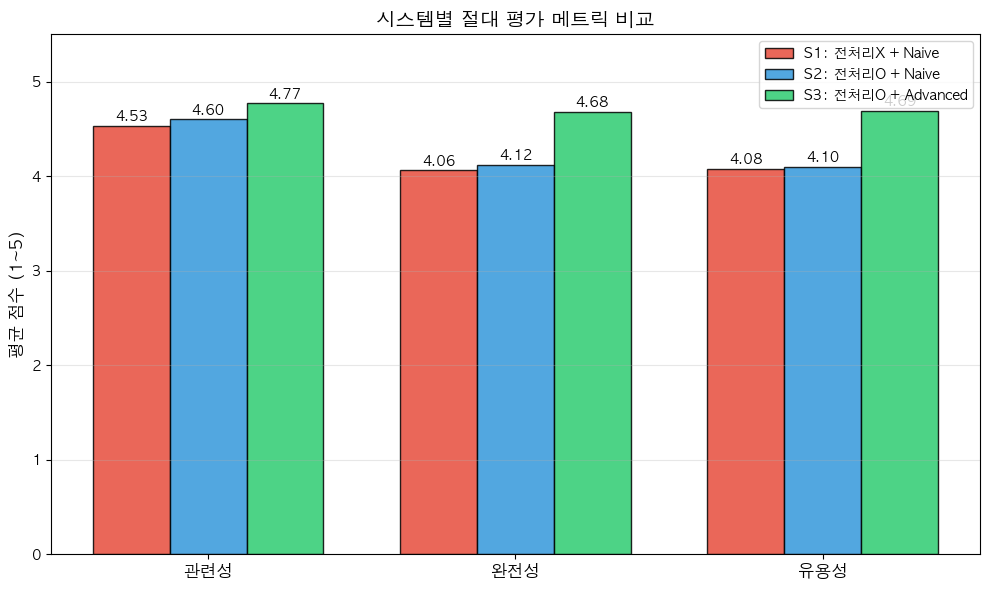

In [28]:
# Cell 10: 시각화 1 - 시스템별 평균 점수 비교 (Grouped Bar Chart)
means = eval_abs.groupby("system")[["relevance", "completeness", "helpfulness"]].mean()
means = means.reindex(["s1", "s2", "s3"])

x = np.arange(3)
width = 0.25
colors = ["#E74C3C", "#3498DB", "#2ECC71"]
labels = [SYSTEMS[k]["name"] for k in ["s1", "s2", "s3"]]
metric_labels = ["관련성", "완전성", "유용성"]

fig, ax = plt.subplots(figsize=(10, 6))
for i, sys_key in enumerate(["s1", "s2", "s3"]):
    vals = means.loc[sys_key].values
    bars = ax.bar(x + i * width, vals, width, label=labels[i], color=colors[i], edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}", ha="center", fontsize=10)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 5.5)
ax.set_ylabel("평균 점수 (1~5)", fontsize=12)
ax.set_title("시스템별 절대 평가 메트릭 비교", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

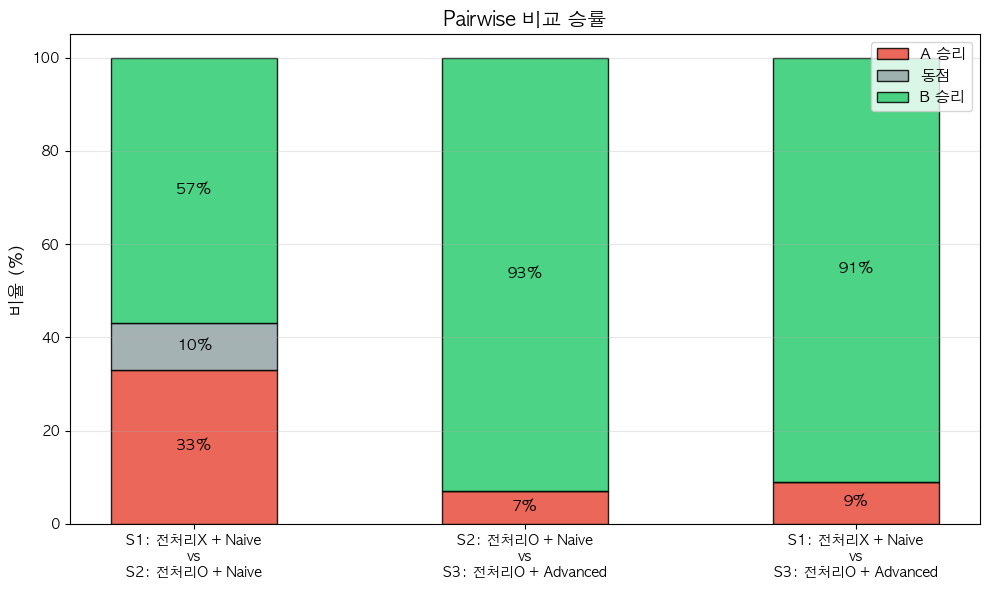

In [29]:
# Cell 11: 시각화 2 - Pairwise 승률 비교 (Stacked Bar)
pair_labels = []
a_pcts, b_pcts, tie_pcts = [], [], []

for pair_name in ["s1_vs_s2", "s2_vs_s3", "s1_vs_s3"]:
    subset = eval_pair[eval_pair["pair"] == pair_name]["winner"]
    total = subset.notna().sum()
    sys_a, sys_b = pair_name.split("_vs_")
    pair_labels.append(f"{SYSTEMS[sys_a]['name']}\nvs\n{SYSTEMS[sys_b]['name']}")
    a_pcts.append((subset == "A").sum() / total * 100)
    b_pcts.append((subset == "B").sum() / total * 100)
    tie_pcts.append((subset == "tie").sum() / total * 100)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pair_labels))
width = 0.5

bars_a = ax.bar(x, a_pcts, width, label="A 승리", color="#E74C3C", edgecolor="black", alpha=0.85)
bars_tie = ax.bar(x, tie_pcts, width, bottom=a_pcts, label="동점", color="#95A5A6", edgecolor="black", alpha=0.85)
bars_b = ax.bar(x, b_pcts, width, bottom=[a + t for a, t in zip(a_pcts, tie_pcts)], label="B 승리", color="#2ECC71", edgecolor="black", alpha=0.85)

# 각 bar에 % 표시
for bars, pcts in [(bars_a, a_pcts), (bars_tie, tie_pcts), (bars_b, b_pcts)]:
    for bar, pct in zip(bars, pcts):
        if pct > 5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f"{pct:.0f}%", ha="center", va="center", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=10)
ax.set_ylabel("비율 (%)", fontsize=12)
ax.set_title("Pairwise 비교 승률", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_pairwise.png", dpi=150, bbox_inches="tight")
plt.show()

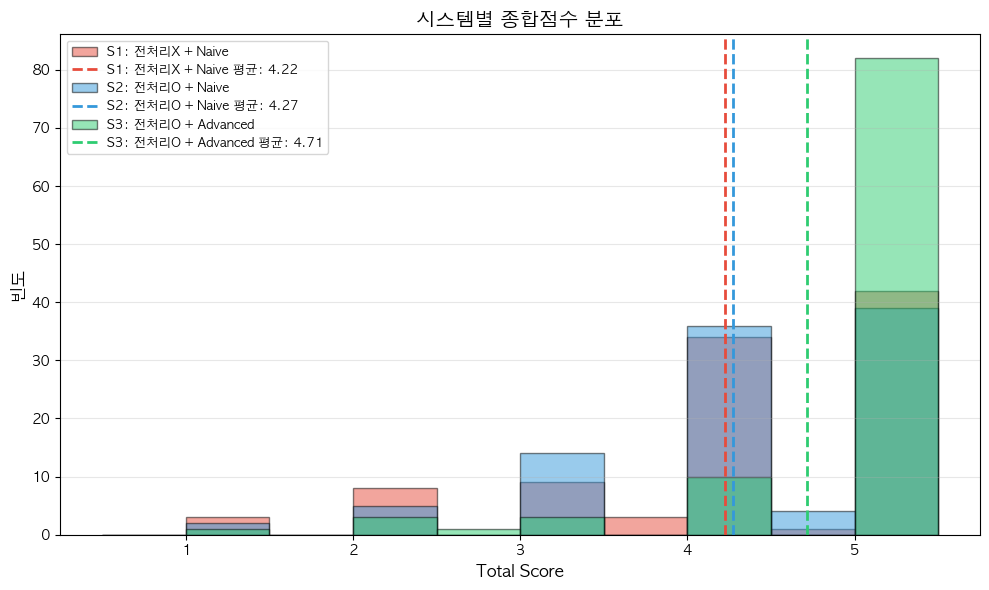

In [30]:
# Cell 12: 시각화 3 - total_score 분포 비교 (히스토그램)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E74C3C", "#3498DB", "#2ECC71"]

for sys_key, color in zip(["s1", "s2", "s3"], colors):
    subset = eval_abs[eval_abs["system"] == sys_key]["total_score"].dropna()
    label = SYSTEMS[sys_key]["name"]
    ax.hist(subset, bins=np.arange(0.5, 6.0, 0.5), alpha=0.5, color=color, label=label, edgecolor="black")
    ax.axvline(subset.mean(), color=color, linestyle="--", linewidth=2,
               label=f"{label} 평균: {subset.mean():.2f}")

ax.set_xlabel("Total Score", fontsize=12)
ax.set_ylabel("빈도", fontsize=12)
ax.set_title("시스템별 종합점수 분포", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/fn/d7ck850j3hb5vkpf9d3t050m0000gn/T/ipykernel_41287/3769071439.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


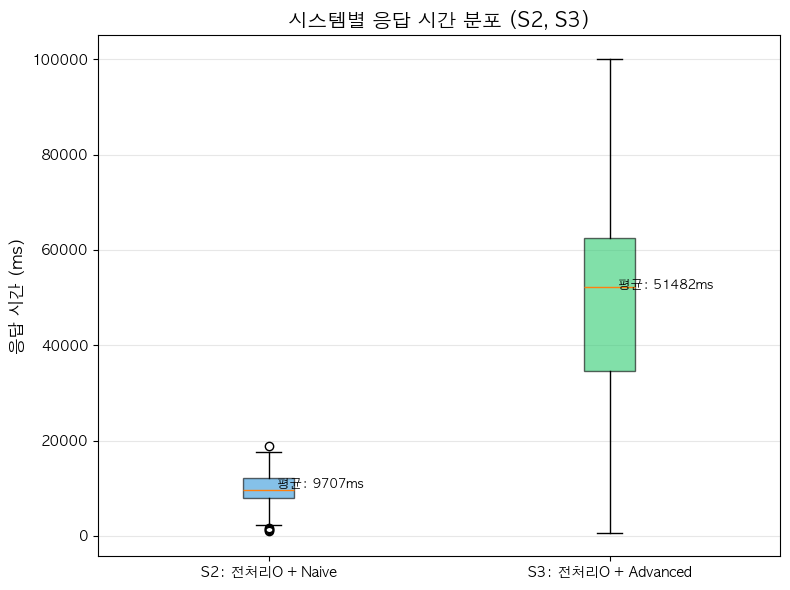

In [31]:
# Cell 13: 시각화 4 - 응답 시간 비교 (S2, S3만 — S1은 latency 없음)
fig, ax = plt.subplots(figsize=(8, 6))
lat_systems = ["s2", "s3"]
lat_labels = [SYSTEMS[k]["name"] for k in lat_systems]
colors = ["#3498DB", "#2ECC71"]

bp = ax.boxplot(
    [all_df[f"latency_{sk}"].dropna().values for sk in lat_systems],
    labels=lat_labels, patch_artist=True, showfliers=True,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("응답 시간 (ms)", fontsize=12)
ax.set_title("시스템별 응답 시간 분포 (S2, S3)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

for i, sk in enumerate(lat_systems):
    mean_val = all_df[f"latency_{sk}"].mean()
    ax.text(i + 1, mean_val, f"  평균: {mean_val:.0f}ms", fontsize=9, va="bottom")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_latency.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Cell 14: S1 vs S3 Pairwise에서 S3가 이긴/진 질문 Top 5
pair_s1s3 = eval_pair[eval_pair["pair"] == "s1_vs_s3"].copy()
pair_s1s3["question"] = all_df["question"].values[pair_s1s3["idx"].values]

# S3 승리 (B 승리) 질문들
s3_wins = pair_s1s3[pair_s1s3["winner"] == "B"]
print("=" * 60)
print(f"S3가 S1을 이긴 질문 ({len(s3_wins)}개 중 Top 5)")
print("=" * 60)
for _, row in s3_wins.head(5).iterrows():
    print(f"  Q: {row['question'][:60]}")
    print(f"     이유: {row['reason'][:80]}\n")

# S1 승리 (A 승리) 질문들
s1_wins = pair_s1s3[pair_s1s3["winner"] == "A"]
print(f"\n{'=' * 60}")
print(f"S1이 S3를 이긴 질문 ({len(s1_wins)}개 중 Top 5)")
print("=" * 60)
for _, row in s1_wins.head(5).iterrows():
    print(f"  Q: {row['question'][:60]}")
    print(f"     이유: {row['reason'][:80]}\n")

S3가 S1을 이긴 질문 (91개 중 Top 5)
  Q: 마이코플라스마 폐렴균의 국내 발생에 대해서 알려줘
     이유: 답변 B는 마이코플라스마 폐렴균의 발생 주기, 주요 유행 연도, 감염 경로, 증상, 항생제 내성 문제 등 다양한 정보를 제공하여 완전성과 유용성

  Q: 조류인플루엔자 인체감염증 치료방법은?
     이유: 답변 B는 조류인플루엔자 인체감염증의 치료 방법뿐만 아니라 주요 증상, 전파 방식, 위험도 및 대응, 격리 및 신고 체계, 예방 방법까지 포괄적

  Q: 요충증 지침 참고자료는 어떻게 검색하나요?
     이유: 답변 B는 요충증 지침을 찾기 위한 다양한 방법을 구체적으로 제시하고 있으며, 질병관리청 웹사이트와 방역통합정보시스템 등 여러 출처를 안내하여 

  Q: 마비성 회백질 척수염이 뭐야?
     이유: 답변 B는 마비성 회백질 척수염의 원인인 폴리오바이러스 감염을 명확히 설명하고 있으며, 이완성 마비라는 주요 특징을 강조하고 있습니다. 또한 초

  Q: 신종감염병증후군 정의는?
     이유: 답변 B는 신종감염병증후군의 정의를 더 구체적으로 설명하고 있으며, '국내 최초 발견', '명확한 병명 미지', '기존 법정감염병에 포함되지 않


S1이 S3를 이긴 질문 (9개 중 Top 5)
  Q: 악구충증 환자관리에 대해 알려줘
     이유: 답변 A는 악구충증 환자 관리에 대한 구체적인 정보를 제공하며, 환자 관리와 접촉자 관리에 대한 명확한 지침을 제시합니다. 반면, 답변 B는 악

  Q: 주혈흡충증는 몇급감염병이야?
     이유: 답변 A는 주혈흡충증을 3급 감염병으로 정확하게 분류하고 있습니다. 반면, 답변 B는 4급으로 잘못된 정보를 제공하고 있습니다. 따라서 정확성과

  Q: 살모넬라균의 전파기간은?
     이유: 답변 A는 살모넬라균의 전파기간에 대한 질문에 직접적으로 답변하고 있으며, 전파기간이 수 일 또는 수 주로 다양하다는 정보를 제공하여 질문에 대

  Q: 리노바이러스의 관련지침에 대해 몇가